# ==========================================
# 1. Load the Test Data
# ==========================================

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score
import joblib

print("Loading test data...")
# Random Forest needs the imputed data
X_test_imputed = pd.read_csv('../data/X_test_clean_imputed.csv')
# Boosting models can handle raw missing data
X_test_raw = pd.read_csv('../data/X_test_clean_raw.csv')
y_test = pd.read_csv('../data/y_test_clean.csv').values.ravel()

Loading test data...


# ==========================================
# 2. Load All Trained Models
# ==========================================

In [33]:
print("Loading models...")
try:
  rf_model = joblib.load("models/random_forest_model.pkl")
  xgb_model = joblib.load("models/xgboost_model.pkl")
  hist_model = joblib.load("models/histboost_model.pkl")

  # Hierarchical Model (Stage 1 & Stage 2)
  hier_stage1 = joblib.load("models/hierarchical_stage1.pkl")
  hier_stage2 = joblib.load("models/hierarchical_stage2.pkl")
except FileNotFoundError:
  print("Error: Make sure all models are saved in the 'models/' folder.")

Loading models...


C:\Users\Kofas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\Kofas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator _BinMapper from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\Kofas\AppData

# ==========================================
# 3. Calculate Flat Model Accuracies
# ==========================================

In [34]:
print("Evaluating models...")
acc_rf = accuracy_score(y_test, rf_model.predict(X_test_imputed.values))
acc_xgb = accuracy_score(y_test, xgb_model.predict(X_test_raw.values))
acc_hist = accuracy_score(y_test, hist_model.predict(X_test_raw.values))

Evaluating models...


C:\Users\Kofas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Kofas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but HistGradientBoostingClassifier was fitted with feature names
  warnings.warn(


# ==========================================
# 4. Calculate Hierarchical Accuracy
# ==========================================

In [37]:
# ==========================================
# 4. Calculate Hierarchical Accuracy (Vectorized)
# ==========================================
print("Evaluating Hierarchical Model...")
# Stage 1: Predict General (0) vs Specialized (1) for all test rows at once
s1_preds = hier_stage1.predict(X_test_raw)

# Initialize final predictions array with General (0)
final_preds = np.zeros(len(y_test), dtype=int)

# Identify indices predicted as Specialized
spec_indices = np.where(s1_preds == 1)[0]

if len(spec_indices) > 0:
  # Extract features for specialized rows only
  X_spec = X_test_raw.iloc[spec_indices]

  # Stage 2: Predict Cardiology (0) vs Nephrology (1) for specialized subset
  s2_preds = hier_stage2.predict(X_spec)

  # Map Stage 2 binary outputs: 0 -> Kardiologiki (1), 1 -> Nefrologiki (2)
  mapped_s2 = np.where(s2_preds == 0, 1, 2)

  # Assign back to final predictions array
  final_preds[spec_indices] = mapped_s2

# For rows where Stage 1 predicted General (0), they are already 0 (Aimolipsies)

acc_hier = accuracy_score(y_test, final_preds)
print(f"Hierarchical Model Overall Accuracy: {acc_hier:.2%}")

Evaluating Hierarchical Model...
Hierarchical Model Overall Accuracy: 65.76%


# ==========================================
# 5. Plot the Final Results!
# ==========================================

C:\Users\Kofas\AppData\Local\Temp\ipykernel_27600\3402241845.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=models, y=accuracies, palette=colors)


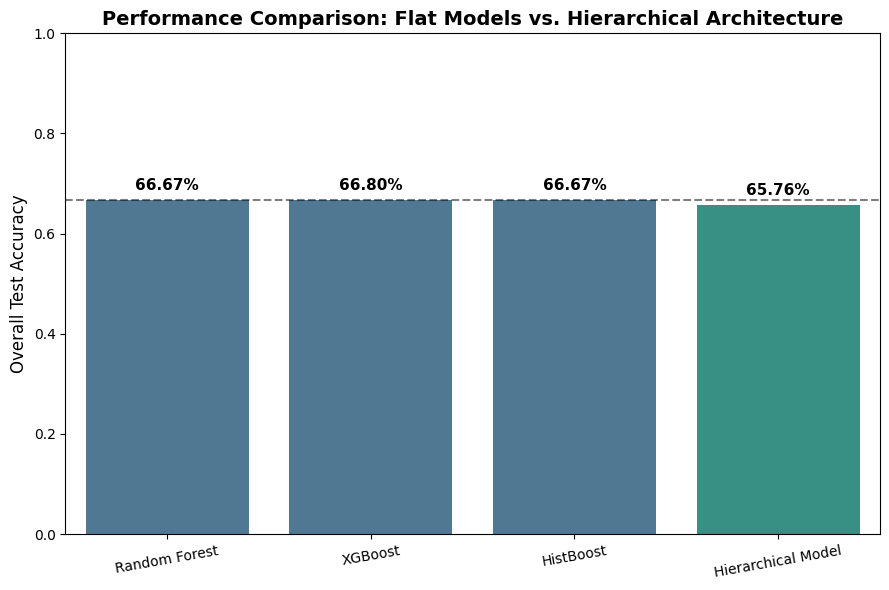

In [38]:
models = [
    'Random Forest',
    'XGBoost',
    'HistBoost',
    'Hierarchical Model',
]
accuracies = [acc_rf, acc_xgb, acc_hist, acc_hier]

plt.figure(figsize=(9, 6))
colors = ['#457b9d', '#457b9d', '#457b9d', '#2a9d8f']
ax = sns.barplot(x=models, y=accuracies, palette=colors)

plt.ylim(0.0, 1.0)
plt.title(
    'Performance Comparison: Flat Models vs. Hierarchical Architecture',
    fontsize=14,
    fontweight='bold',
)
plt.ylabel('Overall Test Accuracy', fontsize=12)
plt.xticks(rotation=10)

# Add the percentage text on top of each bar
for i, v in enumerate(accuracies):
  ax.text(i, v + 0.02, f'{v:.2%}', ha='center', fontweight='bold', fontsize=11)

# Add a dashed line showing the peak accuracy
max_acc = max(accuracies)
plt.axhline(y=max_acc, color='black', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()